In [1]:
import pandas as pd
import os
import scanpy as sc
import anndata as ad
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import shutil
import muon as mu
import scirpy as ir
import anndata
from tqdm import tqdm
from scipy.stats import entropy
import matplotlib.patches as mpatches

import rpy2
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri

from rpy2.robjects.conversion import localconverter

%load_ext rpy2.ipython

/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packag

In [2]:
path = '/home/jupyter/data/ge_korea/results/tcr_analysis/public_clonotype_databases/TCRdb3'
temp_list = []
for i in os.listdir(path):
    if i == '.ipynb_checkpoints':
        continue
    else:
        temp = pd.read_csv((path + '/' + i),sep='\t')
        temp_list.append(temp)

In [3]:
tcrdb = pd.concat(temp_list)

In [4]:
virus = [
 'HIV',
 'Cytomegalovirus',
 'Tropical spastic paraparesis,HTLV-I-associated myelopathy',
 'Yellow fever vaccine',
 'Infectious villitis',
 'YFV17D vaccine',
 'Influenza,Vaccination',
 'Progressive multifocal leukoencephalopathy',
 'HIV,ART',
 'CMV',
 'Acute infectious mononucleosis',
 'Hepatitis C Virus',
 'post COVID-19',
 'COVID-19',
 'Inactivated influenza vaccine',
 'Hepatitis B virus',
 'T cell lymphoproliferative disorder,Hepatitis E virus'
]

In [5]:
adata = sc.read_h5ad('/home/jupyter/data/ge_korea/results/tcr_analysis/mvtcr_adata_new.h5ad')
adata.obs['patient_timepoint'] = adata.obs['patient'].astype(str) + '_' + adata.obs['timepoint'].astype(str)

In [6]:
adata.obs['clonotype_patient'] = adata.obs['clonotype'].astype(str) + '_' + adata.obs['patient'].astype(str)

In [7]:
color_dict = {
    'T naive/early memory Cell' : '#1f77b4',
    'GZMK+ CD8 T progrenitor ex Cell' : '#aec7e8',
    'CD8 Tem Cell' : '#ff7f0e',
    'Tactiv Cell' : '#ffbb78',
    'CD8 HSP T cell' : '#98df8a',
    'CD8 T naive/early memory Cell' : '#d62728',
    'CD4 T naive/early memory Cell' : '#ff9896',
    'CD8 Cytotoxic T Cell' : '#9467bd',
    'Tprolif Cell' : '#8c564b',
    'Treg' : '#c49c94',
    'Tc17' : '#e377c2',
    'Terminal CD8 Tex Cell' : '#f7b6d2',
    'Th17/Tc17' : '#c7c7c7',
    'gd T Cell' : '#bcbd22',
    'NKT' : '#dbdb8d',
    'Th17' : '#17becf',
    'Tnaive Cell' : '#9edae5'
}

In [8]:
patient_progression = adata.obs[['patient','progression']].drop_duplicates()
patient_progression.index = patient_progression['patient']
patient_progression = patient_progression['progression'].to_dict()

In [9]:
blood = pd.read_csv('/home/jupyter/data/ge_korea/results/tcr_analysis/blood_tcr_analysis/blood_CDR3_beta.csv')
blood['patient_timepoint'] = blood['patient'].astype(str) + '_' + blood['timepoint'].astype(str)

In [10]:
blood['V_J_CDR3'] = blood['vGene'].astype(str) + '_' + blood['jGene'] + '_' + blood['aaSeqCDR3'].astype(str)

In [11]:
adata.obs['V_J_CDR3'] = adata.obs['IR_VDJ_1_v_call'].astype(str) + '_' + adata.obs['IR_VDJ_1_j_call'].astype(str) + '_' + adata.obs['IR_VDJ_1_junction_aa'].astype(str)

In [12]:
tcrdb['V_J_CDR3'] = tcrdb['Vregion'].astype(str) + '_' + tcrdb['Jregion'] + '_' + tcrdb['AASeq'].astype(str)

In [13]:
adata.obs['IR_VJ_1_junction_aa']

sample_index
E30_F1_AAACCTGTCTCGGACG      CAFVLHTGTASKLTF
E30_F1_AAACGGGCAACCGCCA       CAAASGDSWGKFQF
E30_F1_AAACGGGCACTTCGAA        CAVGGNQGGKLIF
E30_F1_AAAGATGCAAGTTAAG        CAYRGGSNYKLTF
E30_F1_AAAGATGGTACCGGCT       CALSEPGSQGNLIF
                                 ...        
E29_F1_TTTGGTTAGAAGCCCA        CAVSFYNTDKLIF
E29_F1_TTTGGTTAGATAGTCA         CAEIPNNARLMF
E29_F1_TTTGTCACACGAAACG    CALSRFILTGGGNKLTF
E29_F1_TTTGTCATCGAATCCA        CAAQKNNNARLMF
E29_F1_TTTGTCATCTGGGCCA         CAEIPNNARLMF
Name: IR_VJ_1_junction_aa, Length: 66813, dtype: category
Categories (35638, object): ['CAAAADKLIF', 'CAAAADNFNKFYF', 'CAAAAIYNQGGKLIF', 'CAAAAKTGTASKLTF', ..., 'CYKGAGSSASKIIF', 'CYNDMRF', 'CYVEGSQGNLIF', 'CYYGNNRLAF']

In [14]:
set(tcrdb['AASeq']) & set(adata.obs['IR_VJ_1_junction_aa'])

set()

Text(0, 0.5, '')

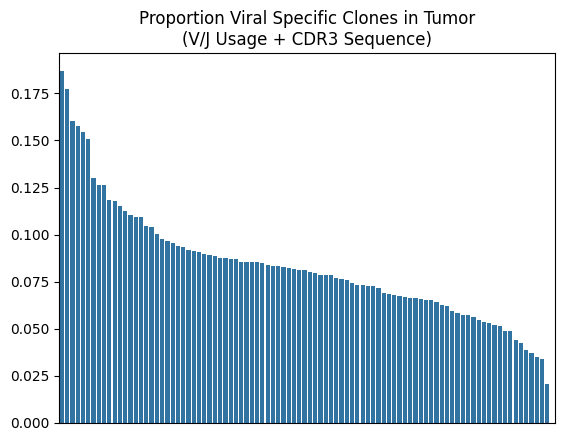

In [15]:
sns.barplot(
    (adata[adata.obs['V_J_CDR3'].isin(tcrdb[tcrdb['Condition'].isin(virus)]['V_J_CDR3'].tolist())].obs['patient_timepoint'].value_counts() / adata.obs['patient_timepoint'].value_counts()).sort_values(ascending=False),
)
plt.title('Proportion Viral Specific Clones in Tumor\n(V/J Usage + CDR3 Sequence)')
plt.xticks([])
plt.ylabel('')

<Axes: ylabel='patient_timepoint'>

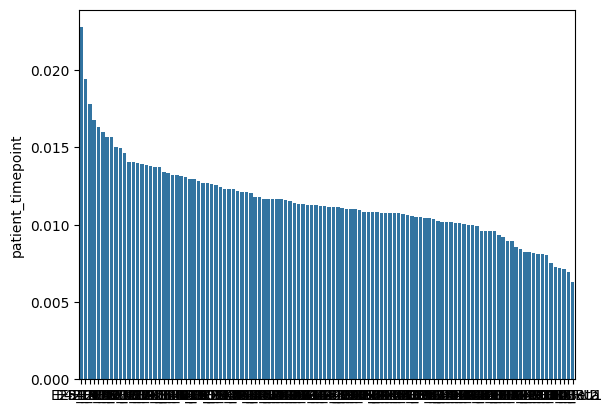

In [16]:
sns.barplot((blood[blood['V_J_CDR3'].isin((tcrdb[tcrdb['Condition'].isin(virus)]['V_J_CDR3'].tolist()))]['patient_timepoint'].value_counts() / blood['patient_timepoint'].value_counts()).sort_values(ascending=False))

In [17]:
bacterial = [
 'Tuberculosis',
 'Salmonella Typhi,Fever',
 'Pleural Tuberculosis',
 'Acne',
 'Salmonella',
 'ESS',
 'Salmonella enterica serova Paratyphi A']

Text(0, 0.5, '')

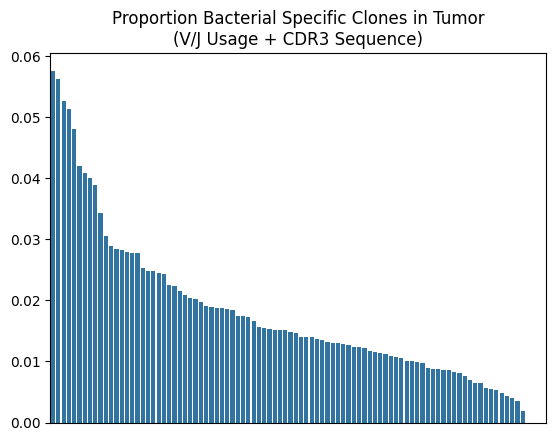

In [18]:
sns.barplot((adata[adata.obs['V_J_CDR3'].isin(tcrdb[tcrdb['Condition'].isin(bacterial)]['V_J_CDR3'].tolist())].obs['patient_timepoint'].value_counts() / adata.obs['patient_timepoint'].value_counts()).sort_values(ascending=False))
plt.title('Proportion Bacterial Specific Clones in Tumor\n(V/J Usage + CDR3 Sequence)')
plt.xticks([])
plt.ylabel('')

Text(0, 0.5, '')

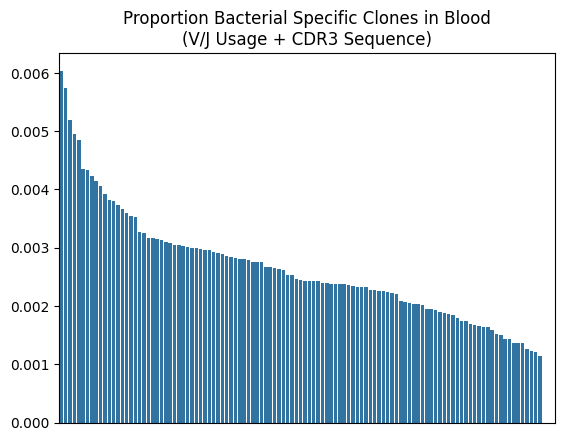

In [19]:
sns.barplot((blood[blood['V_J_CDR3'].isin((tcrdb[tcrdb['Condition'].isin(bacterial)]['V_J_CDR3'].tolist()))]['patient_timepoint'].value_counts() / blood['patient_timepoint'].value_counts()).sort_values(ascending=False))
plt.title('Proportion Bacterial Specific Clones in Blood\n(V/J Usage + CDR3 Sequence)')
plt.xticks([])
plt.ylabel('')

# Pie Charts

# B - F1

In [20]:
adata_bf1 = adata[adata.obs['timepoint'].isin(['B','F1'])]

In [21]:
clonotype_counts_b = adata_bf1[adata_bf1.obs['timepoint'] == 'B'].obs['clonotype_patient'].value_counts()
clonotype_counts_f1 = adata_bf1[adata_bf1.obs['timepoint'] == 'F1'].obs['clonotype_patient'].value_counts()

In [22]:
clonotype_counts_b

11840_E25    83
10475_E15    77
9895_E30     70
3931_E31     60
18991_E20    59
             ..
17170_E18     1
17171_E18     1
17173_E18     1
17174_E18     1
9101_E23      1
Name: clonotype_patient, Length: 14052, dtype: int64

In [23]:
clonotype_counts_bf1 = pd.concat([clonotype_counts_b,
                                  clonotype_counts_f1],axis=1)
clonotype_counts_bf1 = clonotype_counts_bf1.dropna()
clonotype_counts_bf1.columns = ['B','F1']

In [24]:
sample_counts = pd.read_csv('/home/jupyter/data/ge_korea/results/tcr_analysis/cell_counts_by_sample.csv')

In [25]:
sample_counts.index = sample_counts['Sample']
sample_counts

,Sample,Timepoint_Progression,Total,Immune,T cells
Sample,,,,,
E12_B,E12_B,B_Slow,833,644,358
E12_F1,E12_F1,F1_Slow,4651,3929,2906
E12_F2,E12_F2,F2_Slow,4240,3355,2253
E14_B,E14_B,B_Fast,1003,609,322
E14_F1,E14_F1,F1_Fast,1073,521,310
...,...,...,...,...,...
E45_F1,E45_F1,F1_Slow,2391,2032,737
E45_F2,E45_F2,F2_Slow,578,536,83
E46_B,E46_B,B_Slow,1993,436,175


In [26]:
b_props = []
f1_props = []
for i in clonotype_counts_bf1.index:
    temp = i.split('_')[1]
    b_count = sample_counts.loc[temp + '_B','T cells']
    f1_count = sample_counts.loc[temp + '_F1','T cells']
    b_props.append(clonotype_counts_bf1.loc[i,'B'] / b_count)
    f1_props.append(clonotype_counts_bf1.loc[i,'F1'] / f1_count)

In [27]:
clonotype_counts_bf1_norm = pd.DataFrame({'B' : b_props,
                                          'F1' : f1_props},index=clonotype_counts_bf1.index)

In [28]:
expanding_clones = [i for i in clonotype_counts_bf1_norm.index if (clonotype_counts_bf1_norm.loc[i,'F1'] - .001) >= clonotype_counts_bf1_norm.loc[i,'B']]
contracting_clones = [i for i in clonotype_counts_bf1_norm.index if (clonotype_counts_bf1_norm.loc[i,'B'] - .001) >= clonotype_counts_bf1_norm.loc[i,'F1']]

In [29]:
expanding_clones_bf1 = expanding_clones
contracting_clones_bf1 = contracting_clones
nonexpanding_clones_bf1 = [i for i in clonotype_counts_bf1_norm.index if i not in expanding_clones]
shared_clones_bf1 = clonotype_counts_bf1_norm.index.tolist()

In [30]:
dist_b = adata[(adata.obs['clonotype_patient'].isin(
    expanding_clones)) & (
    adata.obs['timepoint'] == 'B'
    )].obs[['clonotype_patient','annot_final']].value_counts().reset_index().pivot(
    columns='annot_final',index='clonotype_patient',values=0
    ).fillna(0).mean(axis=0)
dist_f1 = adata[(adata.obs['clonotype_patient'].isin(
    expanding_clones)) & (
    adata.obs['timepoint'] == 'F1'
    )].obs[['clonotype_patient','annot_final']].value_counts().reset_index().pivot(
    columns='annot_final',index='clonotype_patient',values=0
    ).fillna(0).mean(axis=0)

# F1 - F2

In [31]:
adata_f1f2 = adata[adata.obs['timepoint'].isin(['F1','F2'])]

In [32]:
clonotype_counts_f1 = adata_f1f2[adata_f1f2.obs['timepoint'] == 'F1'].obs['clonotype_patient'].value_counts()
clonotype_counts_f2 = adata_f1f2[adata_f1f2.obs['timepoint'] == 'F2'].obs['clonotype_patient'].value_counts()

In [33]:
clonotype_counts_f1f2 = pd.concat([clonotype_counts_f1,
                                  clonotype_counts_f2],axis=1)
clonotype_counts_f1f2 = clonotype_counts_f1f2.dropna()
clonotype_counts_f1f2.columns = ['F1','F2']

In [34]:
f1_props = []
f2_props = []
for i in clonotype_counts_f1f2.index:
    temp = i.split('_')[1]
    f1_count = sample_counts.loc[temp + '_F1','T cells']
    f2_count = sample_counts.loc[temp + '_F2','T cells']
    f1_props.append(clonotype_counts_f1f2.loc[i,'F1'] / f1_count)
    f2_props.append(clonotype_counts_f1f2.loc[i,'F2'] / f2_count)

In [35]:
clonotype_counts_f1f2_norm = pd.DataFrame({'F1' : f1_props,
                                           'F2' : f2_props},index=clonotype_counts_f1f2.index)

In [36]:
expanding_clones = [i for i in clonotype_counts_f1f2_norm.index if (clonotype_counts_f1f2_norm.loc[i,'F2'] - 0.001) >= clonotype_counts_f1f2_norm.loc[i,'F1']]
contracting_clones = [i for i in clonotype_counts_f1f2_norm.index if (clonotype_counts_f1f2_norm.loc[i,'F1'] - 0.001) >= clonotype_counts_f1f2_norm.loc[i,'F2']]

In [37]:
expanding_clones_f1f2 = expanding_clones
contracting_clones_f1f2 = contracting_clones
nonexpanding_clones_f1f2 = [i for i in clonotype_counts_f1f2_norm.index if i not in expanding_clones]
shared_clones_f1f2 = clonotype_counts_f1f2_norm.index.tolist()

In [38]:
status = []
patient = []
progression = []
clonotype_counts_f1f2_norm_progression = clonotype_counts_f1f2_norm.copy()
del clonotype_counts_f1f2_norm_progression['F1']
del clonotype_counts_f1f2_norm_progression['F2']
for i in clonotype_counts_f1f2_norm_progression.index:
    if i in expanding_clones_f1f2:
        status.append('expanded')
    elif i in contracting_clones_f1f2:
        status.append('contract')
    else:
        status.append('stable')
    patient.append(i.split('_')[1])
    progression.append(patient_progression[i.split('_')[1]])

In [39]:
clonotype_counts_f1f2_norm_progression['status'] = status
clonotype_counts_f1f2_norm_progression['patient'] = patient
clonotype_counts_f1f2_norm_progression['progression'] = progression

In [40]:
clonotype_timepoint = adata.obs[['clonotype_patient','timepoint']].value_counts(
    
).reset_index().pivot(columns='timepoint',index='clonotype_patient',values=0).fillna(0)

clonotype_timepoint = clonotype_timepoint.apply(lambda x: np.where(x != 0, 1, 0))

In [41]:
shared_clones_bf1f2 = list(set(shared_clones_bf1) & set(shared_clones_f1f2))

In [42]:
shared_clones_bf1_only = [i for i in shared_clones_bf1 if i not in shared_clones_bf1f2]
shared_clones_f1f2_only = [i for i in shared_clones_f1f2 if i not in shared_clones_bf1f2]

In [43]:
b_clonotypes = clonotype_timepoint[(clonotype_timepoint['F1'] == 0) & (
    clonotype_timepoint['F2'] == 0)].index.tolist()
f1_clonotypes = clonotype_timepoint[(clonotype_timepoint['B'] == 0) & (
    clonotype_timepoint['F2'] == 0)].index.tolist()
f2_clonotypes = clonotype_timepoint[(clonotype_timepoint['F1'] == 0) & (
    clonotype_timepoint['B'] == 0)].index.tolist()

In [44]:
colors = {
    'All Timepoints Shared' : 'tab:blue',
    'B-F1 Shared Only' : 'tab:orange',
    'F1-F2 Shared Only' : 'tab:green',
    'B Only' : 'tab:red',
    'F1 Only' : 'tab:purple',
    'F2 Only' : 'tab:brown',
    'B-F2 Shared Only' : 'tab:pink'
}

In [45]:
viral_clonotypes = adata[adata.obs['V_J_CDR3'].isin(tcrdb[tcrdb['Condition'].isin(virus)]['V_J_CDR3'].tolist())].obs['clonotype_patient'].unique()
bacterial_clonotypes = adata[adata.obs['V_J_CDR3'].isin(tcrdb[tcrdb['Condition'].isin(bacterial)]['V_J_CDR3'].tolist())].obs['clonotype_patient'].unique()

In [46]:
viral_clone_category = []
for i in viral_clonotypes:
    if i in shared_clones_bf1f2:
        viral_clone_category.append('All Timepoints Shared')
    elif i in shared_clones_bf1_only:
        viral_clone_category.append('B-F1 Shared Only')
    elif i in shared_clones_f1f2_only:
        viral_clone_category.append('F1-F2 Shared Only')
    elif i in b_clonotypes:
        viral_clone_category.append('B Only')
    elif i in f1_clonotypes:
        viral_clone_category.append('F1 Only')
    elif i in f2_clonotypes:
        viral_clone_category.append('F2 Only')
    else:
        viral_clone_category.append('B-F2 Shared Only')

In [47]:
bacterial_clone_category = []
for i in bacterial_clonotypes:
    if i in shared_clones_bf1f2:
        bacterial_clone_category.append('All Timepoints Shared')
    elif i in shared_clones_bf1_only:
        bacterial_clone_category.append('B-F1 Shared Only')
    elif i in shared_clones_f1f2_only:
        bacterial_clone_category.append('F1-F2 Shared Only')
    elif i in b_clonotypes:
        bacterial_clone_category.append('B Only')
    elif i in f1_clonotypes:
        bacterial_clone_category.append('F1 Only')
    elif i in f2_clonotypes:
        bacterial_clone_category.append('F2 Only')
    else:
        bacterial_clone_category.append('B-F2 Shared Only')

Text(0.5, 1.0, 'Breakdown of Viral clonotypes by timepoint sharing')

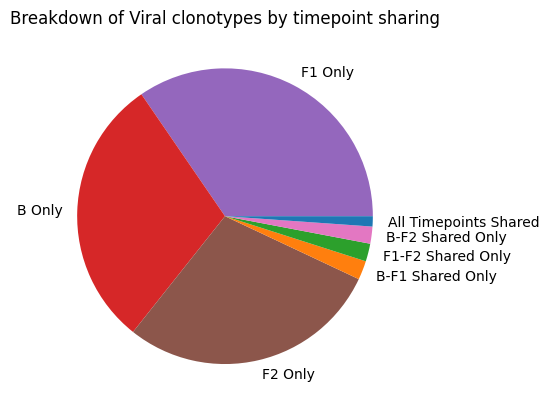

In [48]:
labels = pd.Series(viral_clone_category).value_counts().index
plt.pie(pd.Series(viral_clone_category).value_counts(),labels=labels,
        colors=[colors[i] for i in pd.Series(viral_clone_category).value_counts().index.tolist()])
plt.title('Breakdown of Viral clonotypes by timepoint sharing')

Text(0.5, 1.0, 'Breakdown of Bacterial clonotypes by timepoint sharing')

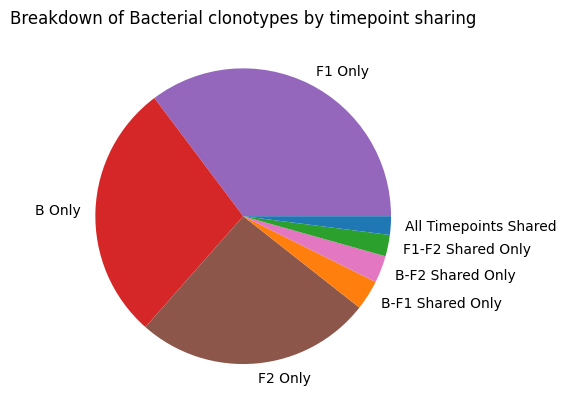

In [49]:
labels = pd.Series(bacterial_clone_category).value_counts().index
plt.pie(pd.Series(bacterial_clone_category).value_counts(),labels=labels,
        colors=[colors[i] for i in pd.Series(bacterial_clone_category).value_counts().index.tolist()])
plt.title('Breakdown of Bacterial clonotypes by timepoint sharing')

In [50]:
viral_clone_category = []
for i in adata.obs['clonotype_patient'].unique():
    if i not in viral_clonotypes:
        if i in shared_clones_bf1f2:
            viral_clone_category.append('All Timepoints Shared')
        elif i in shared_clones_bf1_only:
            viral_clone_category.append('B-F1 Shared Only')
        elif i in shared_clones_f1f2_only:
            viral_clone_category.append('F1-F2 Shared Only')
        elif i in b_clonotypes:
            viral_clone_category.append('B Only')
        elif i in f1_clonotypes:
            viral_clone_category.append('F1 Only')
        elif i in f2_clonotypes:
            viral_clone_category.append('F2 Only')
        else:
            viral_clone_category.append('B-F2 Shared Only')

In [51]:
bacterial_clone_category = []
for i in adata.obs['clonotype_patient'].unique():
    if i not in bacterial_clonotypes:
        if i in shared_clones_bf1f2:
            bacterial_clone_category.append('All Timepoints Shared')
        elif i in shared_clones_bf1_only:
            bacterial_clone_category.append('B-F1 Shared Only')
        elif i in shared_clones_f1f2_only:
            bacterial_clone_category.append('F1-F2 Shared Only')
        elif i in b_clonotypes:
            bacterial_clone_category.append('B Only')
        elif i in f1_clonotypes:
            bacterial_clone_category.append('F1 Only')
        elif i in f2_clonotypes:
            bacterial_clone_category.append('F2 Only')
        else:
            bacterial_clone_category.append('B-F2 Shared Only')

Text(0.5, 1.0, 'Breakdown of non-Viral clonotypes by timepoint sharing')

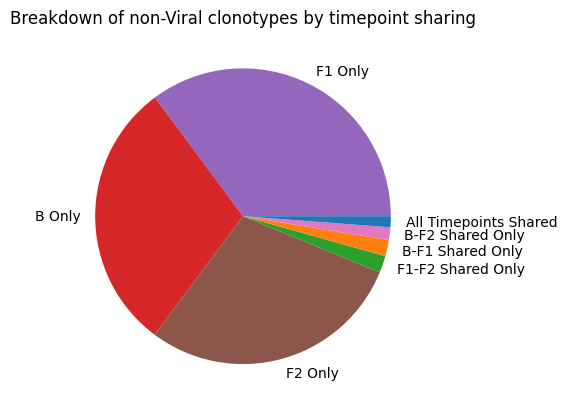

In [52]:
labels = pd.Series(viral_clone_category).value_counts().index
plt.pie(pd.Series(viral_clone_category).value_counts(),labels=labels,
        colors=[colors[i] for i in pd.Series(viral_clone_category).value_counts().index.tolist()])
plt.title('Breakdown of non-Viral clonotypes by timepoint sharing')

Text(0.5, 1.0, 'Breakdown of non-Bacterial clonotypes by timepoint sharing')

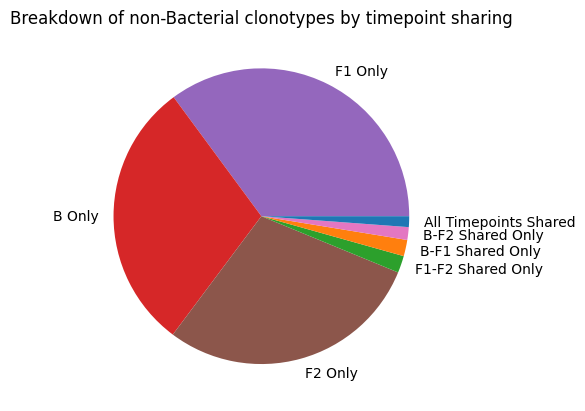

In [53]:
labels = pd.Series(bacterial_clone_category).value_counts().index
plt.pie(pd.Series(bacterial_clone_category).value_counts(),labels=labels,
        colors=[colors[i] for i in pd.Series(bacterial_clone_category).value_counts().index.tolist()])
plt.title('Breakdown of non-Bacterial clonotypes by timepoint sharing')

In [54]:
viral_clone_category = []
for i in adata[(adata.obs['clonotype_patient'].isin(viral_clonotypes)) & (
    adata.obs['progression'] == 'Slow'
)].obs['clonotype_patient'].unique():
    if i in shared_clones_bf1f2:
        viral_clone_category.append('All Timepoints Shared')
    elif i in shared_clones_bf1_only:
        viral_clone_category.append('B-F1 Shared Only')
    elif i in shared_clones_f1f2_only:
        viral_clone_category.append('F1-F2 Shared Only')
    elif i in b_clonotypes:
        viral_clone_category.append('B Only')
    elif i in f1_clonotypes:
        viral_clone_category.append('F1 Only')
    elif i in f2_clonotypes:
        viral_clone_category.append('F2 Only')
    else:
        viral_clone_category.append('B-F2 Shared Only')

In [55]:
bacterial_clone_category = []
for i in adata[(adata.obs['clonotype_patient'].isin(bacterial_clonotypes)) & (
    adata.obs['progression'] == 'Slow'
)].obs['clonotype_patient'].unique():
    if i in shared_clones_bf1f2:
        bacterial_clone_category.append('All Timepoints Shared')
    elif i in shared_clones_bf1_only:
        bacterial_clone_category.append('B-F1 Shared Only')
    elif i in shared_clones_f1f2_only:
        bacterial_clone_category.append('F1-F2 Shared Only')
    elif i in b_clonotypes:
        bacterial_clone_category.append('B Only')
    elif i in f1_clonotypes:
        bacterial_clone_category.append('F1 Only')
    elif i in f2_clonotypes:
        bacterial_clone_category.append('F2 Only')
    else:
        bacterial_clone_category.append('B-F2 Shared Only')

Text(0.5, 1.0, 'Breakdown of Viral clonotypes by timepoint sharing, slow')

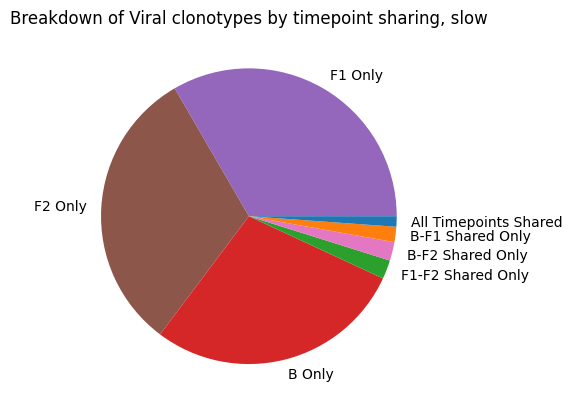

In [56]:
labels = pd.Series(viral_clone_category).value_counts().index
plt.pie(pd.Series(viral_clone_category).value_counts(),labels=labels,
        colors=[colors[i] for i in pd.Series(viral_clone_category).value_counts().index.tolist()])
plt.title('Breakdown of Viral clonotypes by timepoint sharing, slow')

Text(0.5, 1.0, 'Breakdown of Bacterial clonotypes by timepoint sharing, slow')

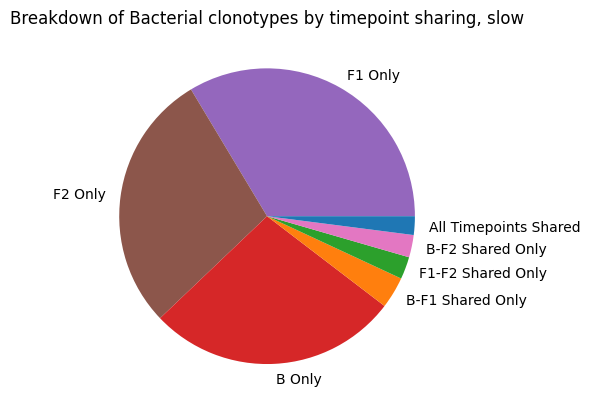

In [57]:
labels = pd.Series(bacterial_clone_category).value_counts().index
plt.pie(pd.Series(bacterial_clone_category).value_counts(),labels=labels,
        colors=[colors[i] for i in pd.Series(bacterial_clone_category).value_counts().index.tolist()])
plt.title('Breakdown of Bacterial clonotypes by timepoint sharing, slow')

In [58]:
viral_clone_category = []
for i in adata[(adata.obs['clonotype_patient'].isin(viral_clonotypes)) & (
    adata.obs['progression'] == 'Fast'
)].obs['clonotype_patient'].unique():
    if i in shared_clones_bf1f2:
        viral_clone_category.append('All Timepoints Shared')
    elif i in shared_clones_bf1_only:
        viral_clone_category.append('B-F1 Shared Only')
    elif i in shared_clones_f1f2_only:
        viral_clone_category.append('F1-F2 Shared Only')
    elif i in b_clonotypes:
        viral_clone_category.append('B Only')
    elif i in f1_clonotypes:
        viral_clone_category.append('F1 Only')
    elif i in f2_clonotypes:
        viral_clone_category.append('F2 Only')
    else:
        viral_clone_category.append('B-F2 Shared Only')

In [59]:
bacterial_clone_category = []
for i in adata[(adata.obs['clonotype_patient'].isin(bacterial_clonotypes)) & (
    adata.obs['progression'] == 'Fast'
)].obs['clonotype_patient'].unique():
    if i in shared_clones_bf1f2:
        bacterial_clone_category.append('All Timepoints Shared')
    elif i in shared_clones_bf1_only:
        bacterial_clone_category.append('B-F1 Shared Only')
    elif i in shared_clones_f1f2_only:
        bacterial_clone_category.append('F1-F2 Shared Only')
    elif i in b_clonotypes:
        bacterial_clone_category.append('B Only')
    elif i in f1_clonotypes:
        bacterial_clone_category.append('F1 Only')
    elif i in f2_clonotypes:
        bacterial_clone_category.append('F2 Only')
    else:
        bacterial_clone_category.append('B-F2 Shared Only')

Text(0.5, 1.0, 'Breakdown of Viral clonotypes by timepoint sharing, fast')

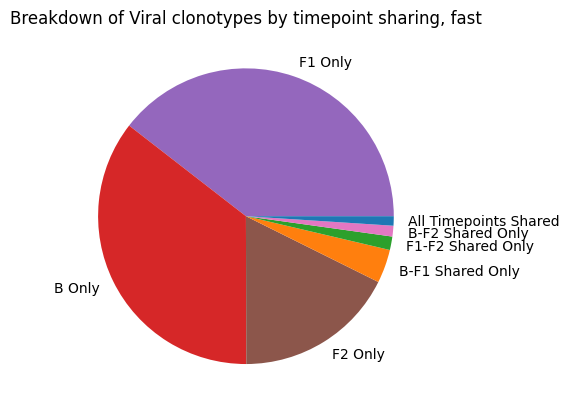

In [60]:
labels = pd.Series(viral_clone_category).value_counts().index
plt.pie(pd.Series(viral_clone_category).value_counts(),labels=labels,
        colors=[colors[i] for i in pd.Series(viral_clone_category).value_counts().index.tolist()])
plt.title('Breakdown of Viral clonotypes by timepoint sharing, fast')

Text(0.5, 1.0, 'Breakdown of Bacterial clonotypes by timepoint sharing, fast')

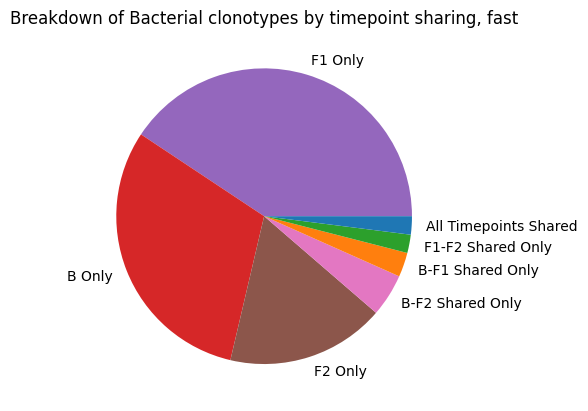

In [61]:
labels = pd.Series(bacterial_clone_category).value_counts().index
plt.pie(pd.Series(bacterial_clone_category).value_counts(),labels=labels,
        colors=[colors[i] for i in pd.Series(bacterial_clone_category).value_counts().index.tolist()])
plt.title('Breakdown of Bacterial clonotypes by timepoint sharing, fast')